In [1]:
%load_ext autoreload
%autoreload 2
import h5py 
import scipy 
import numpy as np 
import matplotlib.pyplot as plt 
from comborun import ComboRun



In [2]:
def generate_filenames(ranges, a, let='a'):
    files = []
    for r in ranges:
        files +=[f'/home/tejvarmay/scattering_data/data/newdata/data00{i}_analysis_{let}{a}/spts.cxi' for i in range(r[0], r[1])]
    return files

ps40nm = [(651,657)]
ps30nm = [(658, 664)]
ps20nm = [(665, 671)]
ps50nm = [(674, 683)]

fe_he42 = [(684, 694)]
fe_he28 = [(695, 705)]


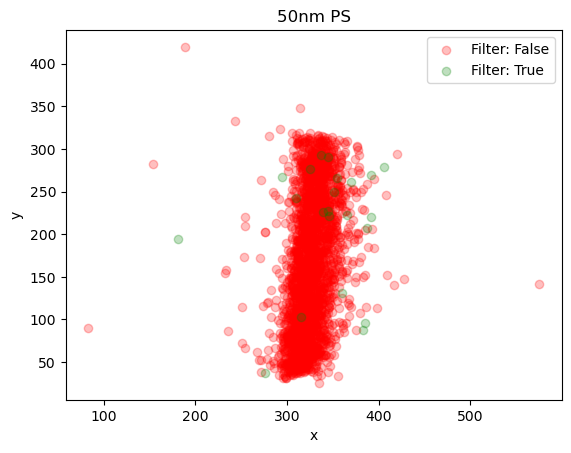

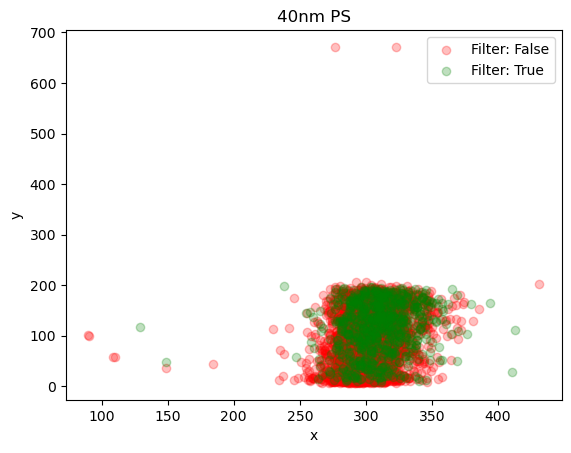

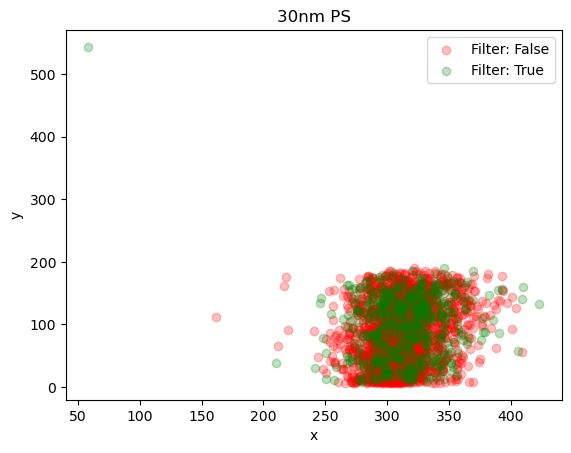

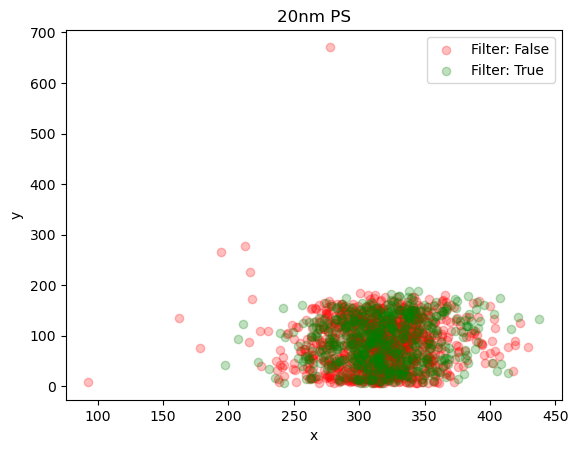

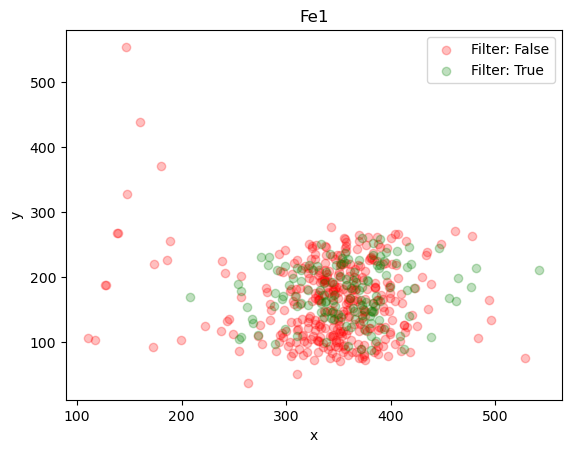

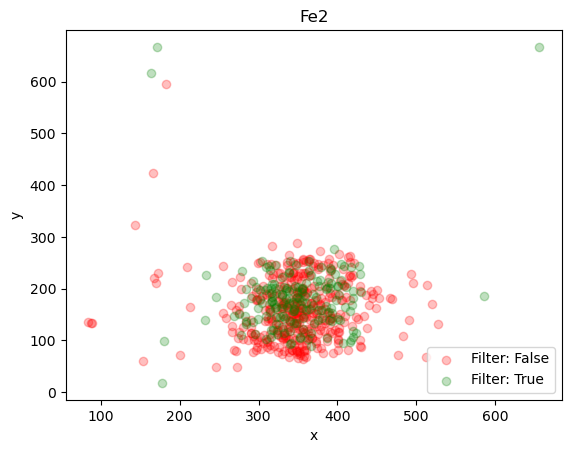

In [3]:
r15_ps50nm = ComboRun(generate_filenames(ps50nm, 15))
r15_ps40nm = ComboRun(generate_filenames(ps40nm, 15))
r15_ps30nm = ComboRun(generate_filenames(ps30nm, 15))
r15_ps20nm = ComboRun(generate_filenames(ps20nm, 15))

r5_ps50nm = ComboRun(generate_filenames(ps50nm, 5))
r5_ps40nm = ComboRun(generate_filenames(ps40nm, 5))
r5_ps30nm = ComboRun(generate_filenames(ps30nm, 5))
r5_ps20nm = ComboRun(generate_filenames(ps20nm, 5))

r15_fe_he42 = ComboRun(generate_filenames(fe_he42, 15))
r5_fe_he42 = ComboRun(generate_filenames(fe_he42, 5))
r15_fe_he28 = ComboRun(generate_filenames(fe_he28, 15))
r5_fe_he28 = ComboRun(generate_filenames(fe_he28, 5))

tit = ['50nm PS', '40nm PS', '30nm PS', '20nm PS', 'Fe1', 'Fe2']
for r15,r5, t in zip([r15_ps50nm,r15_ps40nm,r15_ps30nm,r15_ps20nm, r15_fe_he42, r15_fe_he28], [r5_ps50nm,r5_ps40nm,r5_ps30nm,r5_ps20nm, r5_fe_he42, r5_fe_he28], tit):
    r15.filter_focused(r5, focus_threshold=0.8)
    r15.scatter_xy()
    plt.title(t)
    #r15.hist_i()
    

In [4]:
np.median(r15_fe_he28.peak_is[r15_fe_he28.filter]**(1/6))
## ferritin ~130 A or 13nm

4.846326429725124

[7.681325534259235, 6.597944787343927, 5.405229932101279, 4.596054732140535]
Linear fit: 0.1044852726140344*m+2.413154204904765
ferritin median I: 4.846326429725124
ferritin actual size: ~130 A or 13nm


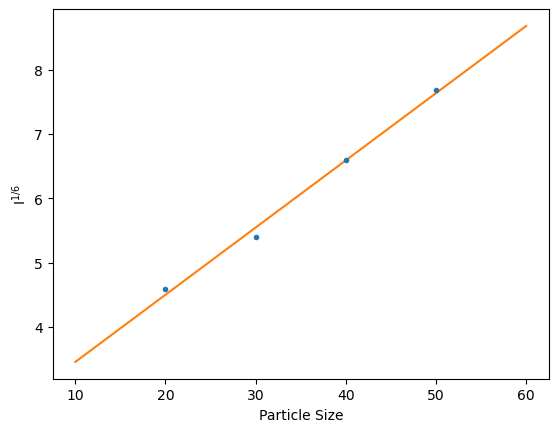

In [5]:
inten_med = []
ps_size = [50, 40, 30, 20,]
for r15 in [r15_ps50nm,r15_ps40nm,r15_ps30nm,r15_ps20nm]:
    inten_med.append(np.median(r15.peak_is[r15.filter]**(1/6)),)


print(inten_med)
popt1, pcov1 = scipy.optimize.curve_fit(lambda x,m,c: m*x+c, ps_size, inten_med)

plt.figure()
x = np.linspace(10, 60)
plt.errorbar(x=ps_size, y=inten_med, marker='.', ls='None', label='data')
plt.plot(x, popt1[0]*x+popt1[1],label='fit')
plt.xlabel('Particle Size')
plt.ylabel('I$^{1/6}$')
print(f'Linear fit: {popt1[0]}*m+{popt1[1]}')
print('ferritin median I:', np.median(r15_fe_he28.peak_is[r15_fe_he28.filter]**(1/6)))
print('ferritin actual size: ~130 A or 13nm')